<a href="https://colab.research.google.com/github/MonishDY/AI-Track/blob/main/Module%203%20-%20Machine%20Learning/Assignment%205/Monish_DY_Assignment_5_ML_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Apriori Algorithm and Principal Component Analysis (PCA)**

## **Overall Objectives**

* To implement the **Apriori algorithm** for frequent itemset mining.
* To generate and analyze **association rules** from transaction data.
* To understand **market basket analysis** using support and association rules.
* To implement Apriori **without external data-mining libraries**.
* To apply **PCA for dimensionality reduction** and variance analysis.
* To visualize PCA-transformed data and explained variance.
* To analyze PCA performance on **high-dimensional datasets**.
* To use PCA for **reconstruction-based anomaly detection**.

## **1. Apriori from CSV Dataset**

Read transaction data from a CSV file and perform Apriori analysis.

Tasks:
1. Load CSV file
2. Convert transactions into itemsets
3. Find frequent itemsets
4. Generate association rules.

**Objective:** To perform Apriori analysis on transaction data.

## **2. Market Basket Analysis**

Implement Apriori to identify products that are frequently purchased together.

- Find frequent itemsets
- Display support values
- Generate association rules

Use appropriate Dataset

**Objective:** To identify products that are frequently purchased together using Apriori.

## **3. Apriori Algorithm Using Python**

Create a Python implementation without using external data-mining libraries.

**Objective:** To implement the Apriori algorithm using Python.

## **4. Apply PCA to the Iris Dataset**

Apply PCA to the Iris Dataset.

**Objective:** To apply PCA to the Iris dataset.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
# Import dataset
iris = load_iris()

X = iris.data
y = iris.target

In [14]:
# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [24]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Target"] = y
pca_df.head()

,PC1,PC2,Target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


In [16]:
# Explained Variance Ratio
variance_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance": pca.explained_variance_ratio_
})

variance_df

,Principal Component,Explained Variance
0,PC1,0.729624
1,PC2,0.228508


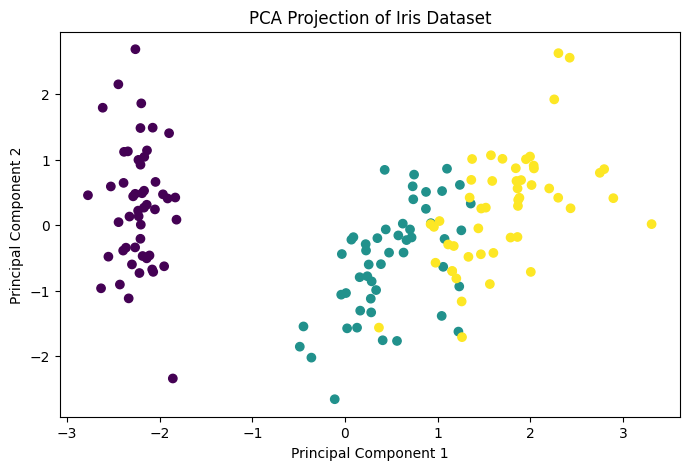

In [17]:
# PCA Scatter Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")
plt.show()

## **5. Principal components needed to retain 95% variance.**

Determine the minimum number of principal components needed to retain 95% variance.

**Objective:** To determine the minimum number of principal components needed to retain 95% variance.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data

In [19]:
# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [21]:
# Calculate Variances Ratios
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

variance_df = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.729624,0.729624
1,2,0.228508,0.958132
2,3,0.036689,0.994821
3,4,0.005179,1.000000


In [25]:
# Determine minimum components
n_components = (cumulative_variance >= 0.95).argmax() + 1

print("Minimum number of components:", n_components)
print("Retained variance:", cumulative_variance[n_components - 1])

Minimum number of components: 2
Retained variance: 0.9581320720000166


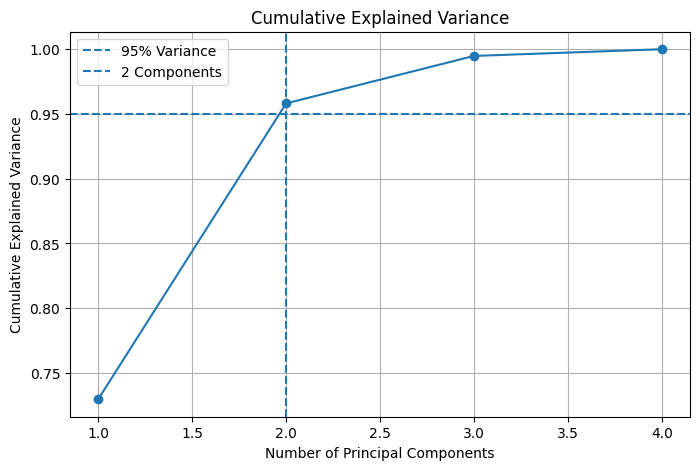

In [29]:
# Plot graph
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(0.95, linestyle="--", label="95% Variance")
plt.axvline(n_components, linestyle="--", label=f"{n_components} Components")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

In [26]:
# PCA with Required Components
pca_95 = PCA(n_components=n_components)
X_pca = pca_95.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


## **6. Compute the explained variance ratio of each principal component.**

Given a set of eigenvalues, write a program to compute the explained variance ratio of each principal component.

Input  eigenvalues = [4.5, 2.1, 1.0, 0.4]

**Objective:** To compute the explained variance ratio of each principal component.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# Eigen values
eigenvalues = np.array([4.5, 2.1, 1.0, 0.4])

# Calculate Explained Variance Ratio
explained_variance_ratio = eigenvalues / eigenvalues.sum()
explained_variance_ratio

array([0.5625, 0.2625, 0.125 , 0.05  ])

In [33]:
# Display Results
variance_df = pd.DataFrame({
    "Principal Component": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_variance_ratio
})

variance_df

,Principal Component,Eigenvalue,Explained Variance Ratio
0,1,4.5,0.5625
1,2,2.1,0.2625
2,3,1.0,0.1250
3,4,0.4,0.0500


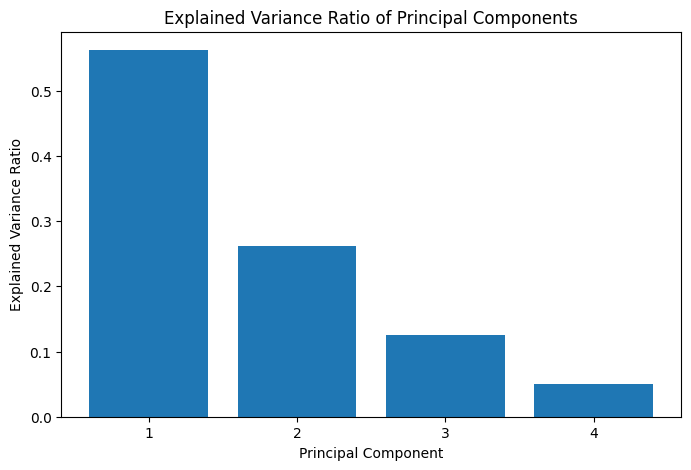

In [35]:
# Plot Explained Variance Ratio
plt.figure(figsize=(8, 5))

plt.bar(
    variance_df["Principal Component"],
    variance_df["Explained Variance Ratio"]
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of Principal Components")
plt.xticks(range(1, len(eigenvalues) + 1))
plt.show()

## **7. Dimensionality Reduction**

Reduce a dataset having 8 features to:

- 4 dimensions
- 2 dimensions

Compare the retained variance.

**Objective:** To reduce the dataset dimensions and compare the retained variance.

In [36]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
X, y = make_regression(
    n_samples=500,
    n_features=8,
    random_state=42
)

X = StandardScaler().fit_transform(X)

In [39]:
# Apply PCA with 4 and 2 components
pca_4 = PCA(n_components=4)
X_4 = pca_4.fit_transform(X)

pca_2 = PCA(n_components=2)
X_2 = pca_2.fit_transform(X)

In [40]:
# Calculate Explained Variance Ratio
variance = pd.DataFrame({
    'Dimensions': ['4 Dimensions', '2 Dimensions'],
    'Retained Variance': [
        pca_4.explained_variance_ratio_.sum(),
        pca_2.explained_variance_ratio_.sum()
    ]
})

variance

,Dimensions,Retained Variance
0,4 Dimensions,0.542328
1,2 Dimensions,0.279248


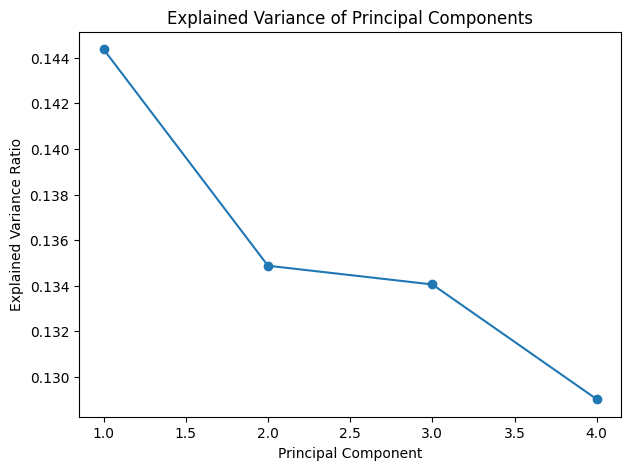

In [41]:
# Plot graph
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 5),
    pca_4.explained_variance_ratio_,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance of Principal Components')

plt.show()

## **8. PCA Visualization**

Apply PCA on a dataset with more than 3 features and project it into 2D.

Generate:
- Scatter plot
- Explained variance plot

**Objective:** To project a dataset into 2D using PCA and visualize the results.

In [42]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

X = StandardScaler().fit_transform(X)

In [45]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Target'] = y
pca_df.head()

,PC1,PC2,Target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


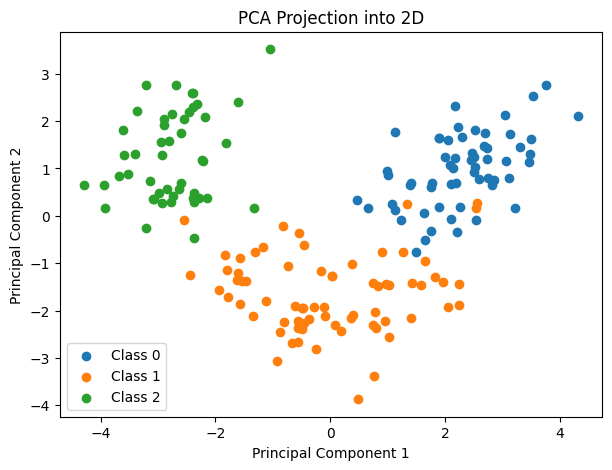

In [46]:
# Plot graph
plt.figure(figsize=(7, 5))

for target in sorted(pca_df['Target'].unique()):
    data = pca_df[pca_df['Target'] == target]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        label=f'Class {target}'
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection into 2D')
plt.legend()
plt.show()

## **9. PCA for High-Dimensional Data**

Given a dataset containing:
10000 samples  1000 features

Perform:
- PCA transformation
- Variance analysis
- Runtime measurement
- Memory usage analysis

**Objective:** To perform PCA on high-dimensional data and analyze its performance.

In [54]:
import numpy as np
import pandas as pd
import time
import tracemalloc
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [49]:
# Create dataset
X, y = make_regression(
    n_samples=10000,
    n_features=1000,
    random_state=42
)

X = StandardScaler().fit_transform(X)

In [51]:
# Calculate necessary parameters
tracemalloc.start()
start_time = time.time()

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

runtime = time.time() - start_time

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

memory_usage = peak / (1024 ** 2)

In [52]:
# Display Results
print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)
print("Retained Variance:", pca.explained_variance_ratio_.sum())
print("Number of Components:", pca.n_components_)
print("Runtime:", round(runtime, 4), "seconds")
print("Peak Memory Usage:", round(memory_usage, 2), "MB")

Original Shape: (10000, 1000)
Reduced Shape: (10000, 908)
Retained Variance: 0.9503870078661443
Number of Components: 908
Runtime: 1.5737 seconds
Peak Memory Usage: 83.94 MB


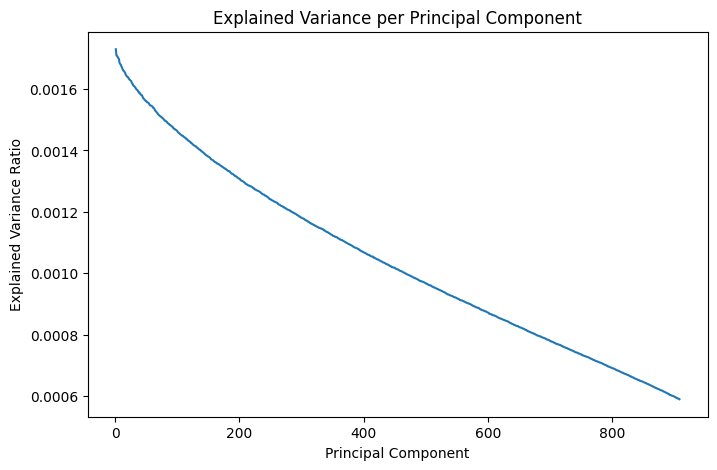

In [55]:
# Plot graph
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Principal Component')

plt.show()

## **10. PCA-Based Anomaly Detection**

Develop a PCA model for anomaly detection.

Requirements
- Train PCA on normal data
- Reconstruct observations
- Compute reconstruction error
- Detect anomalies

**Objective:** To develop a PCA model for anomaly detection.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [58]:
# Create dataset
np.random.seed(42)

normal_data = np.random.normal(0, 1, (500, 5))
anomaly_data = np.random.normal(5, 1, (20, 5))

data = np.vstack([normal_data, anomaly_data])

In [59]:
# Perform standardization
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)
data_scaled = scaler.transform(data)

In [60]:
# Apply PCA
pca = PCA(n_components=2)
pca.fit(normal_scaled)

PCA(n_components=2)

In [61]:
# Reconstruct Observations and Compute Error
data_pca = pca.transform(data_scaled)
data_reconstructed = pca.inverse_transform(data_pca)

reconstruction_error = np.mean(
    (data_scaled - data_reconstructed) ** 2,
    axis=1
)

error_df = pd.DataFrame({
    'Observation': range(len(data)),
    'Reconstruction_Error': reconstruction_error
})

error_df.head()

,Observation,Reconstruction_Error
0,0,0.228662
1,1,0.166694
2,2,1.552698
3,3,0.808846
4,4,0.784454


In [62]:
# Detect Anomalies
threshold = np.percentile(
    reconstruction_error[:len(normal_data)],
    95
)

error_df['Anomaly'] = (
    error_df['Reconstruction_Error'] > threshold
)

print("Threshold:", threshold)
print("Number of Anomalies:", error_df['Anomaly'].sum())

error_df

Threshold: 1.5286081986218776
Number of Anomalies: 45


,Observation,Reconstruction_Error,Anomaly
0,0,0.228662,False
1,1,0.166694,False
2,2,1.552698,True
3,3,0.808846,False
4,4,0.784454,False
...,...,...,...
515,515,17.206517,True
516,516,17.415442,True
517,517,8.749649,True
518,518,12.929254,True


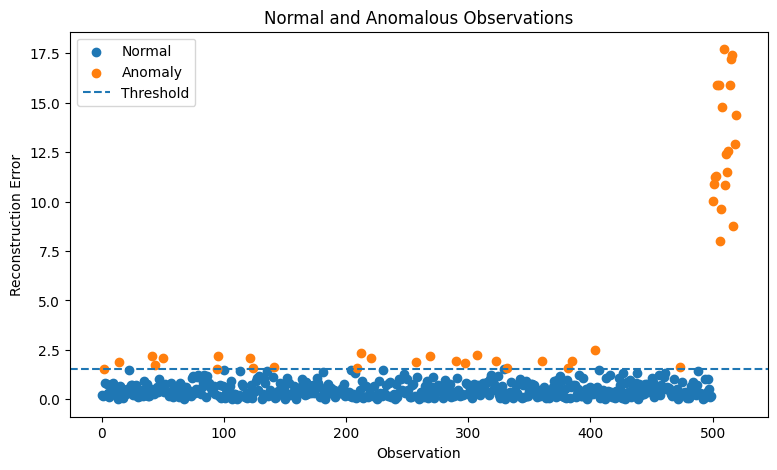

In [63]:
# Plot graph
plt.figure(figsize=(9, 5))

normal = error_df[~error_df['Anomaly']]
anomalies = error_df[error_df['Anomaly']]

plt.scatter(
    normal['Observation'],
    normal['Reconstruction_Error'],
    label='Normal'
)

plt.scatter(
    anomalies['Observation'],
    anomalies['Reconstruction_Error'],
    label='Anomaly'
)

plt.axhline(
    threshold,
    linestyle='--',
    label='Threshold'
)

plt.xlabel('Observation')
plt.ylabel('Reconstruction Error')
plt.title('Normal and Anomalous Observations')
plt.legend()
plt.show()